# Notebook 01 — Data Preprocessing Pipeline (V2)
**Thesis**: A Prescriptive and Explainable Hybrid ML Framework for T2D Risk Prediction
**Dataset**: DiaHealth Diabetes Dataset (single dataset)

### Pipeline Steps
1. Install & import dependencies
2. Set Kaggle paths
3. Load DiaHealth dataset
4. Data profiling & EDA
5. Cleaning & plausibility filtering
6. Encoding (gender, diabetic label)
7. IQR Winsorisation
8. Feature engineering (domain-informed)
9. Train-test split (80/20 stratified)
10. Class imbalance — BorderlineSMOTE / ADASYN
11. Boruta feature selection (checkpoint)
12. Save processed dataset

### Checkpoint Strategy
- Steps 3-8: single all-or-nothing checkpoint (`nb01_preprocessed.pkl`)
- Step 11 (Boruta): per-run checkpoint (`nb01_boruta_diahealth.pkl`)
- Step 9 (splits): checkpoint (`nb01_splits.pkl`)


In [ ]:
# ============================================================
# 1. INSTALL DEPENDENCIES
# ============================================================
# scipy>=1.14,<1.17 : fixes numpy-2.x AttributeError AND satisfies AutoGluon
!pip install -q "scipy>=1.14.0,<1.17" "seaborn>=0.13.2" --upgrade
!pip install -q xgboost lightgbm catboost autogluon shap lime dice-ml
!pip install -q boruta imbalanced-learn optuna plotly matplotlib pandas scikit-learn joblib

# Restart so upgraded scipy is loaded fresh into memory


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All imports successful.')


All imports successful.


## 2. Set Kaggle Paths

In [ ]:
# ============================================================
# 2. SET KAGGLE PATHS
# ============================================================
# Upload 'DiaHealth_Diabetes Dataset.csv' as a Kaggle dataset.
# In the notebook: Add Data -> search for your dataset.
# The file will appear at /kaggle/input/<dataset-slug>/
# Adjust KAGGLE_INPUT below to match your dataset slug.

KAGGLE_INPUT = '/kaggle/input/datasets/ahnaf007/diahealth'
RAW_DATA     = KAGGLE_INPUT
EXP_DIR      = '/kaggle/working/exp_v2'

for subdir in [
    'data/raw', 'data/processed', 'checkpoints',
    'models',
    'results/xai', 'results/counterfactuals', 'results/summary'
]:
    os.makedirs(os.path.join(EXP_DIR, subdir), exist_ok=True)

PROCESSED_DIR = os.path.join(EXP_DIR, 'data', 'processed')
MODELS_DIR    = os.path.join(EXP_DIR, 'models')
CKPT_DIR      = os.path.join(EXP_DIR, 'checkpoints')

print(f'Raw data    : {RAW_DATA}')
print(f'Experiment  : {EXP_DIR}')
print(f'Processed   : {PROCESSED_DIR}')
print(f'Checkpoints : {CKPT_DIR}')


Raw data    : /kaggle/input/datasets/ahnaf007/diahealth
Experiment  : /kaggle/working/exp_v2
Processed   : /kaggle/working/exp_v2/data/processed
Checkpoints : /kaggle/working/exp_v2/checkpoints


## 3-8. Load, Clean, Encode, Engineer Features

In [ ]:
# ============================================================
# 3-8. LOAD -> CLEAN -> ENCODE -> ENGINEER  (single checkpoint)
# ============================================================

CKPT_PREPROCESS = os.path.join(CKPT_DIR, 'nb01_preprocessed.pkl')
TARGET_COL      = 'diabetic'

if os.path.exists(CKPT_PREPROCESS):
    print('Loading preprocessed data from checkpoint...')
    ckpt          = joblib.load(CKPT_PREPROCESS)
    df            = ckpt['df']
    encoding_maps = ckpt['encoding_maps']
    print(f'   Loaded  shape: {df.shape}')
else:
    # --- Step 3: Load ---
    print('--- Step 3: Loading dataset ---')
    CSV_FILE = os.path.join(RAW_DATA, 'DiaHealth_Diabetes Dataset.csv')
    df = pd.read_csv(CSV_FILE)
    print(f'  Shape: {df.shape}')
    print(f'  Columns: {df.columns.tolist()}')

    # --- Step 4: Profiling ---
    print('\n--- Step 4: Profiling ---')
    print(f'  Missing values: {df.isnull().sum().sum()}')
    print(f'  Duplicates   : {df.duplicated().sum()}')
    print(df.describe().round(2))

    # --- Step 5: Cleaning ---
    print('\n--- Step 5: Cleaning ---')
    n_before = len(df)
    df = df.drop_duplicates()
    print(f'  Removed {n_before - len(df)} duplicate rows')
    bounds = {
        'age':          (0, 120),
        'pulse_rate':   (30, 250),
        'systolic_bp':  (60, 280),
        'diastolic_bp': (30, 160),
        'glucose':      (0, 600),
        'height':       (100, 250),
        'weight':       (20, 300),
        'bmi':          (10,  70),
    }
    for col, (lo, hi) in bounds.items():
        if col in df.columns:
            df[col] = df[col].clip(lo, hi)
    print('  Plausibility clipping done.')

    # --- Step 6: Encoding ---
    print('\n--- Step 6: Encoding ---')
    encoding_maps = {}
    if df['gender'].dtype == object:
        gender_map          = {'Male': 1, 'Female': 0}
        df['gender']        = df['gender'].map(gender_map)
        encoding_maps['gender'] = gender_map
    if df[TARGET_COL].dtype == object:
        target_map          = {'Yes': 1, 'No': 0}
        df[TARGET_COL]      = df[TARGET_COL].map(target_map)
        encoding_maps[TARGET_COL] = target_map
    print('  Encoding done.')

    # --- Step 7: IQR Winsorisation ---
    print('\n--- Step 7: IQR Winsorisation ---')
    num_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
    continuous = [c for c in num_cols if df[c].nunique() > 5 and c != TARGET_COL]
    clipped    = 0
    for col in continuous:
        Q1, Q3  = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR     = Q3 - Q1
        lo_, hi_ = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n        = ((df[col] < lo_) | (df[col] > hi_)).sum()
        df[col]  = df[col].clip(lo_, hi_)
        clipped += n
    print(f'  Clipped {clipped} outlier values.')

    # --- Step 8: Feature Engineering ---
    print('\n--- Step 8: Feature Engineering ---')
    n_before_fe = df.shape[1]
    if 'systolic_bp' in df.columns and 'diastolic_bp' in df.columns:
        df['bp_ratio']       = df['systolic_bp'] / (df['diastolic_bp'] + 1)
        df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']
    if 'bmi' in df.columns and 'age' in df.columns:
        df['bmi_age']        = df['bmi'] * df['age']
    if 'glucose' in df.columns and 'bmi' in df.columns:
        df['glucose_bmi']    = df['glucose'] * df['bmi']
    if all(c in df.columns for c in ['hypertensive', 'cardiovascular_disease', 'stroke']):
        df['cardio_risk']    = df['hypertensive'] + df['cardiovascular_disease'] + df['stroke']
    if all(c in df.columns for c in ['family_diabetes', 'family_hypertension']):
        df['family_risk']    = df['family_diabetes'] + df['family_hypertension']
    new_feats = df.columns.tolist()[n_before_fe:]
    print(f'  Features: {n_before_fe} -> {df.shape[1]}   New: {new_feats}')

    # --- Save checkpoint ---
    joblib.dump({'df': df, 'encoding_maps': encoding_maps}, CKPT_PREPROCESS)
    print(f'\n  Checkpoint saved -> {CKPT_PREPROCESS}')

print('\nSteps 3-8 complete. Final shape:', df.shape)
print('Target distribution:')
print(df[TARGET_COL].value_counts())


Loading preprocessed data from checkpoint...
   Loaded  shape: (5437, 21)

Steps 3-8 complete. Final shape: (5437, 21)
Target distribution:
diabetic
0    5093
1     344
Name: count, dtype: int64


### Correlation Heatmap

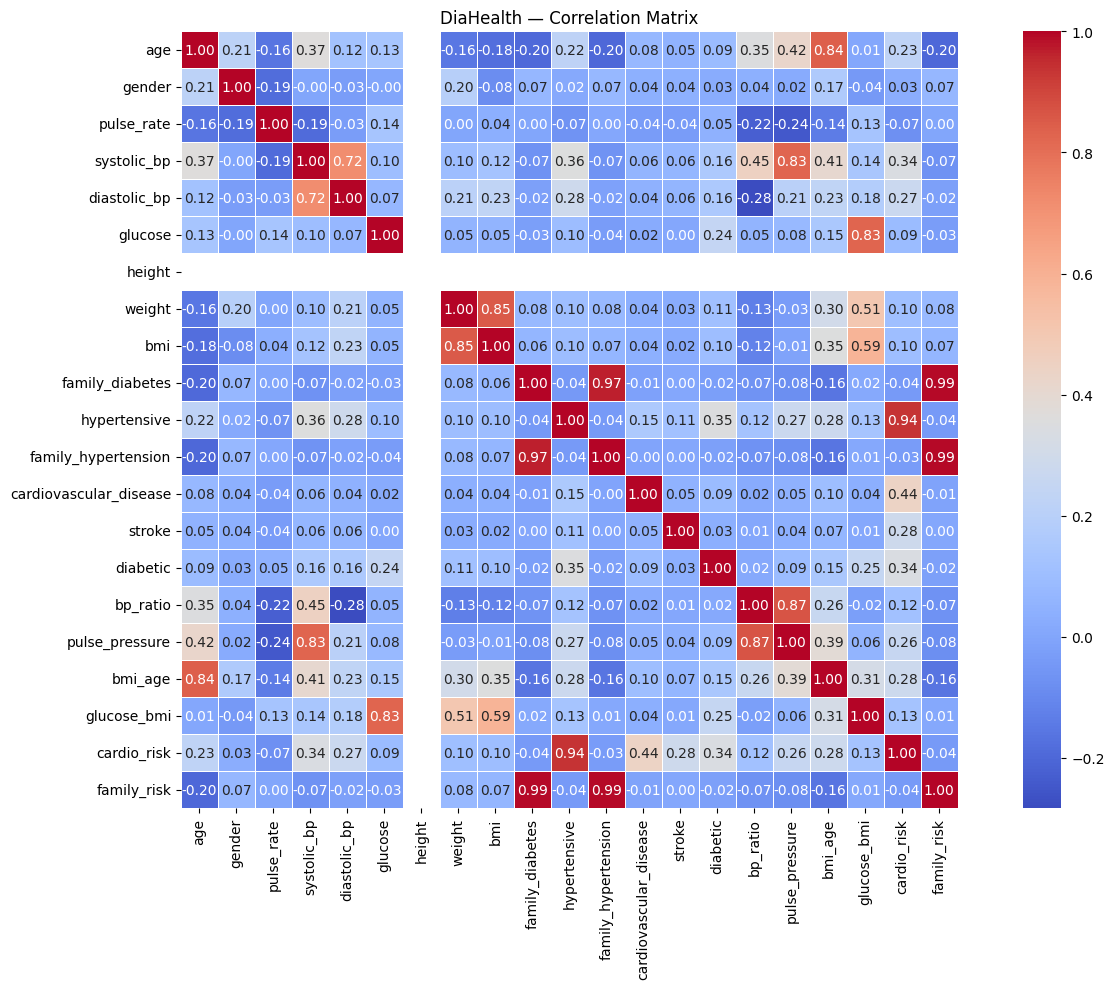

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('DiaHealth — Correlation Matrix')
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'results', 'correlation_heatmap.png'), dpi=150)
plt.show()


## 9. Train-Test Split

In [ ]:
# ============================================================
# 9. TRAIN-TEST SPLIT (80/20 stratified)
# ============================================================
CKPT_SPLITS = os.path.join(CKPT_DIR, 'nb01_splits.pkl')

if os.path.exists(CKPT_SPLITS):
    print('Loading splits from checkpoint...')
    sp = joblib.load(CKPT_SPLITS)
    X_train = sp['X_train']
    X_test  = sp['X_test']
    y_train = sp['y_train']
    y_test  = sp['y_test']
    print(f'  Train: {X_train.shape} | Test: {X_test.shape}')
else:
    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
    print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
    print(f'Positive rate  Train: {y_train.mean():.2%}  Test: {y_test.mean():.2%}')
    sp = {'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test}
    joblib.dump(sp, CKPT_SPLITS)
    print(f'  Splits checkpoint saved.')

print('Splits ready.')


Train: (4349, 20)  |  Test: (1088, 20)
Positive rate  Train: 6.32%  Test: 6.34%
  Splits checkpoint saved.
Splits ready.


## 10. Class Imbalance — BorderlineSMOTE / ADASYN

In [ ]:
# ============================================================
# 10. CLASS IMBALANCE HANDLING
# ============================================================
resampled = {'original': (X_train.copy(), y_train.copy())}

try:
    bsm = BorderlineSMOTE(random_state=RANDOM_STATE, kind='borderline-1')
    X_bsm, y_bsm = bsm.fit_resample(X_train, y_train)
    resampled['borderline_smote'] = (X_bsm, y_bsm)
    print(f'BorderlineSMOTE: {y_train.value_counts().to_dict()} -> {pd.Series(y_bsm).value_counts().to_dict()}')
except Exception as e:
    print(f'BorderlineSMOTE failed ({e}), trying SMOTE...')
    try:
        sm = SMOTE(random_state=RANDOM_STATE)
        X_sm, y_sm = sm.fit_resample(X_train, y_train)
        resampled['smote'] = (X_sm, y_sm)
        print(f'SMOTE: {pd.Series(y_sm).value_counts().to_dict()}')
    except Exception as e2:
        print(f'SMOTE also failed: {e2}')

try:
    ada = ADASYN(random_state=RANDOM_STATE)
    X_ada, y_ada = ada.fit_resample(X_train, y_train)
    resampled['adasyn'] = (X_ada, y_ada)
    print(f'ADASYN: {pd.Series(y_ada).value_counts().to_dict()}')
except Exception as e:
    print(f'ADASYN failed: {e}')

# Choose: borderline_smote > smote > adasyn > original
chosen_method = 'original'
for method in ['borderline_smote', 'smote', 'adasyn', 'original']:
    if method in resampled:
        X_train_res, y_train_res = resampled[method]
        chosen_method = method
        break

print(f'\nUsing: {chosen_method}')
print(f'  Resampled shape: {X_train_res.shape}  Positive rate: {y_train_res.mean():.2%}')


BorderlineSMOTE: {0: 4074, 1: 275} -> {0: 4074, 1: 4074}
ADASYN: {1: 4083, 0: 4074}

Using: borderline_smote
  Resampled shape: (8148, 20)  Positive rate: 50.00%


## 11. Boruta Feature Selection

**This is the slowest step (~5-10 min).** A checkpoint is saved; if the session crashes, re-running this cell will skip Boruta and load from checkpoint.

In [ ]:
# ============================================================
# 11. BORUTA FEATURE SELECTION (checkpoint)
# ============================================================
CKPT_BORUTA = os.path.join(CKPT_DIR, 'nb01_boruta_diahealth.pkl')

if os.path.exists(CKPT_BORUTA):
    boruta_result = joblib.load(CKPT_BORUTA)
    selected      = boruta_result['selected']
    print(f'Loaded from checkpoint ({len(selected)} features selected)')
    print(f'  Confirmed : {boruta_result["confirmed"]}')
    print(f'  Tentative : {boruta_result["tentative"]}')
else:
    print(f'Running Boruta on {X_train_res.shape[1]} features...')
    rf = RandomForestClassifier(
        n_jobs=-1, class_weight='balanced', max_depth=7, random_state=RANDOM_STATE)
    boruta = BorutaPy(
        rf, n_estimators='auto', verbose=2,
        random_state=RANDOM_STATE, max_iter=200)
    boruta.fit(X_train_res.values, y_train_res.values)

    feature_names = X_train_res.columns.tolist()
    confirmed     = [f for f, s in zip(feature_names, boruta.support_) if s]
    tentative     = [f for f, s in zip(feature_names, boruta.support_weak_) if s]
    rejected      = [f for f in feature_names if f not in confirmed and f not in tentative]
    selected      = confirmed + tentative
    if len(selected) == 0:
        selected = feature_names
        print('  No features selected, using all.')

    boruta_result = {
        'confirmed': confirmed, 'tentative': tentative,
        'rejected': rejected,   'selected': selected,
    }
    joblib.dump(boruta_result, CKPT_BORUTA)
    print(f'  Confirmed ({len(confirmed)}): {confirmed}')
    print(f'  Tentative ({len(tentative)}): {tentative}')
    print(f'  Rejected  ({len(rejected)}): {rejected}')
    print(f'  Checkpoint saved -> {CKPT_BORUTA}')

print(f'\nBoruta complete. {len(selected)} features selected.')


Running Boruta on 20 features...
Iteration: 	1 / 200
Confirmed: 	0
Tentative: 	20
Rejected: 	0
Iteration: 	2 / 200
Confirmed: 	0
Tentative: 	20
Rejected: 	0
Iteration: 	3 / 200
Confirmed: 	0
Tentative: 	20
Rejected: 	0
Iteration: 	4 / 200
Confirmed: 	0
Tentative: 	20
Rejected: 	0
Iteration: 	5 / 200
Confirmed: 	0
Tentative: 	20
Rejected: 	0
Iteration: 	6 / 200
Confirmed: 	0
Tentative: 	20
Rejected: 	0
Iteration: 	7 / 200
Confirmed: 	0
Tentative: 	20
Rejected: 	0
Iteration: 	8 / 200
Confirmed: 	14
Tentative: 	3
Rejected: 	3
Iteration: 	9 / 200
Confirmed: 	14
Tentative: 	3
Rejected: 	3
Iteration: 	10 / 200
Confirmed: 	14
Tentative: 	3
Rejected: 	3
Iteration: 	11 / 200
Confirmed: 	14
Tentative: 	3
Rejected: 	3
Iteration: 	12 / 200
Confirmed: 	14
Tentative: 	3
Rejected: 	3
Iteration: 	13 / 200
Confirmed: 	14
Tentative: 	3
Rejected: 	3
Iteration: 	14 / 200
Confirmed: 	14
Tentative: 	3
Rejected: 	3
Iteration: 	15 / 200
Confirmed: 	14
Tentative: 	3
Rejected: 	3
Iteration: 	16 / 200
Confirmed:

## 12. Save Processed Dataset

In [ ]:
# ============================================================
# 12. SAVE PROCESSED DATA
# ============================================================
selected = boruta_result['selected']

X_train_boruta     = X_train[selected]
X_test_boruta      = X_test[selected]
X_train_res_boruta = X_train_res[selected]

scaler = StandardScaler()
scaler.fit(X_train_boruta)

save_dict = {
    'X_train_full':       X_train,
    'X_test_full':        X_test,
    'X_train_boruta':     X_train_boruta,
    'X_test_boruta':      X_test_boruta,
    'X_train_res_boruta': X_train_res_boruta,
    'y_train_res':        y_train_res,
    'y_train':            y_train,
    'y_test':             y_test,
    'boruta_confirmed':   boruta_result['confirmed'],
    'boruta_tentative':   boruta_result['tentative'],
    'boruta_rejected':    boruta_result['rejected'],
    'feature_names_full': X_train.columns.tolist(),
    'feature_names_boruta': selected,
    'target_col':         TARGET_COL,
    'scaler':             scaler,
}

joblib.dump(save_dict, os.path.join(PROCESSED_DIR, 'diahealth_processed.pkl'))

meta = {
    'datasets':      ['diahealth'],
    'target_cols':   {'diahealth': TARGET_COL},
    'encoding_maps': encoding_maps,
    'random_state':  RANDOM_STATE,
    'version':       'v2',
}
joblib.dump(meta, os.path.join(PROCESSED_DIR, 'meta.pkl'))

print('Saved: diahealth_processed.pkl  &  meta.pkl')
print(f'  All features     : {len(save_dict["feature_names_full"])}')
print(f'  Boruta selected  : {len(selected)} -> {selected}')
print(f'  Train (original) : {X_train_boruta.shape}')
print(f'  Train (resampled): {X_train_res_boruta.shape}')
print(f'  Test             : {X_test_boruta.shape}')
print()
print('Notebook 01 complete! Proceed to 02_modelling.ipynb')


Saved: diahealth_processed.pkl  &  meta.pkl
  All features     : 20
  Boruta selected  : 16 -> ['age', 'gender', 'pulse_rate', 'systolic_bp', 'diastolic_bp', 'glucose', 'weight', 'bmi', 'hypertensive', 'bp_ratio', 'pulse_pressure', 'bmi_age', 'glucose_bmi', 'cardio_risk', 'family_hypertension', 'family_risk']
  Train (original) : (4349, 16)
  Train (resampled): (8148, 16)
  Test             : (1088, 16)

Notebook 01 complete! Proceed to 02_modelling.ipynb
